In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('all_stocks_adjusted.csv')

# Get a random sample of 100 rows
# random_state ensures reproducibility, so running the code again will yield the same 100 rows
random_100_rows = df.sample(n=100, random_state=42) 

# Convert the sampled DataFrame to a CSV file
# index=False prevents writing the DataFrame index as a column in the CSV
random_100_rows.to_csv('random_100_rows.csv', index=False)

In [83]:
class FinancialFeatureEngineer:
    """
    Comprehensive feature engineering for financial price prediction
    Binary classification: BUY if return > 0, SELL otherwise
    Includes all original ~120 features
    """
    
    def __init__(self, offset_days=20):
        self.offset_days = offset_days
        self.fitted_volatility_threshold = None
        
    def calculate_returns_and_moving_averages(self, df):
        """Calculate returns and moving averages"""
        df = df.copy()
        
        # Basic returns
        df['1d_return'] = df.groupby('Symbol')['Close'].pct_change()
        df['5d_ROC'] = df.groupby('Symbol')['Close'].pct_change(5)
        df['10d_ROC'] = df.groupby('Symbol')['Close'].pct_change(10)
        df['20d_ROC'] = df.groupby('Symbol')['Close'].pct_change(20)
        df['momentum_ratio'] = df.groupby('Symbol')['Close'].transform(lambda x: x / x.shift(5))
        
        # Simple Moving Averages
        df['SMA_10'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(10).mean())
        df['SMA_20'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(20).mean())
        df['SMA_50'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(50).mean())
        
        # Exponential Moving Averages
        df['EMA_12'] = df.groupby('Symbol')['Close'].transform(lambda x: x.ewm(span=12).mean())
        df['EMA_26'] = df.groupby('Symbol')['Close'].transform(lambda x: x.ewm(span=26).mean())
        df['ema_5'] = df.groupby('Symbol')['Close'].transform(lambda x: x.ewm(span=5).mean())
        df['ema_20'] = df.groupby('Symbol')['Close'].transform(lambda x: x.ewm(span=20).mean())
        
        # Price to MA ratios
        df['close_to_SMA_10'] = df['Close'] / df['SMA_10']
        df['close_to_SMA_20'] = df['Close'] / df['SMA_20']
        df['close_to_SMA_50'] = df['Close'] / df['SMA_50']
        df['ema_ratio'] = df['ema_5'] / df['ema_20']
        
        return df

    
    def calculate_momentum_indicators(self, df):
        """Calculate comprehensive momentum indicators"""
        # MACD
        df['MACD'] = df['EMA_12'] - df['EMA_26']
        df['MACD_signal'] = df.groupby('Symbol')['MACD'].transform(lambda x: x.ewm(span=9).mean())
        df['MACD_histogram'] = df['MACD'] - df['MACD_signal']
        
        # RSI
        def calculate_rsi(series, window=14):
            delta = series.diff()
            gain = delta.where(delta > 0, 0)
            loss = -delta.where(delta < 0, 0)
            
            avg_gain = gain.rolling(window=window).mean()
            avg_loss = loss.rolling(window=window).mean()
            
            rs = avg_gain / avg_loss
            rsi = 100 - (100 / (1 + rs))
            return rsi
        
        df['RSI_14'] = df.groupby('Symbol')['Close'].transform(calculate_rsi)
        
        
        
        def compute_williams_r(df):
            # If there's only one symbol, skip groupby to avoid DataFrame return
            if df['Symbol'].nunique() == 1:
                high14 = df['High'].rolling(14).max()
                low14 = df['Low'].rolling(14).min()
                wr = (high14 - df['Close']) / (high14 - low14) * -100
                return wr

            # Otherwise, handle groupwise
            return df.groupby('Symbol', group_keys=False).apply(
                lambda g: (g['High'].rolling(14).max() - g['Close']) /
                          (g['High'].rolling(14).max() - g['Low'].rolling(14).min()) * -100
            ).reset_index(level=0, drop=True)

        # then:
        df['williams_R_14'] = compute_williams_r(df)

        
        return df
    
    def calculate_volatility_features(self, df):
        """Calculate comprehensive volatility features"""
        # Volatility measures
        df['volatility_10'] = df.groupby('Symbol')['1d_return'].transform(lambda x: x.rolling(10).std())
        df['volatility_20'] = df.groupby('Symbol')['1d_return'].transform(lambda x: x.rolling(20).std())
        df['volatility_60'] = df.groupby('Symbol')['1d_return'].transform(lambda x: x.rolling(60).std())
        
        # Normalized range
        df['normalized_range'] = (df['High'] - df['Low']) / df['Close']
        df['rolling_std_5'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(5).std())
        df['rolling_std_20'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(20).std())
        df['volatility_ratio'] = df['rolling_std_5'] / df['rolling_std_20']
        
        # Average True Range (ATR)
        def calculate_atr(group):
            high_low = group['High'] - group['Low']
            high_close_prev = abs(group['High'] - group['Close'].shift(1))
            low_close_prev = abs(group['Low'] - group['Close'].shift(1))
            true_range = pd.concat([high_low, high_close_prev, low_close_prev], axis=1).max(axis=1)
            return true_range.rolling(14).mean()
        
        df['ATR_14'] = df.groupby('Symbol').apply(calculate_atr).reset_index(level=0, drop=True)
        df['true_range'] = df['High'] - df['Low']
        df['atr_14'] = df.groupby('Symbol')['true_range'].transform(lambda x: x.rolling(14).mean())
        
        # Bollinger Bands
        df['bollinger_upper'] = df['SMA_20'] + 2 * df['volatility_20']
        df['bollinger_lower'] = df['SMA_20'] - 2 * df['volatility_20']
        df['bollinger_position'] = (df['Close'] - df['bollinger_lower']) / (df['bollinger_upper'] - df['bollinger_lower'])
        
        # Sharpe ratio
        df['sharpe_20'] = df.groupby('Symbol')['1d_return'].transform(
            lambda x: x.rolling(20).mean() / x.rolling(20).std()
        )
        
        return df
    
    def calculate_volume_features(self, df):
        """Calculate comprehensive volume features"""
        # Volume features
        df['volume_SMA_20'] = df.groupby('Symbol')['Volume'].transform(lambda x: x.rolling(20).mean())
        df['volume_SMA_10'] = df.groupby('Symbol')['Volume'].transform(lambda x: x.rolling(10).mean())
        df['volume_SMA_5'] = df.groupby('Symbol')['Volume'].transform(lambda x: x.rolling(5).mean())
        
        df['volume_ratio'] = df['Volume'] / df['volume_SMA_20']
        df['vol_ma_5'] = df.groupby('Symbol')['Volume'].transform(lambda x: x.rolling(5).mean())
        df['vol_ma_20'] = df.groupby('Symbol')['Volume'].transform(lambda x: x.rolling(20).mean())
        df['vol_ratio'] = df['vol_ma_5'] / df['vol_ma_20']
        df['vwap_ratio'] = df['Close'] / df['VWAP']
        
        # On-Balance Volume (OBV)
        def calculate_obv(group):
            obv = (group['Volume'] * np.where(group['Close'] > group['Close'].shift(1), 1, 
                                           np.where(group['Close'] < group['Close'].shift(1), -1, 0))).cumsum()
            return obv
        
        df['OBV'] = df.groupby('Symbol').apply(calculate_obv).reset_index(level=0, drop=True)
        
        # Volume-return correlation
        def volume_return_corr(group):
            return group['1d_return'].rolling(20).corr(group['Volume'])
        
        df['volume_return_corr_20'] = df.groupby('Symbol').apply(volume_return_corr).reset_index(level=0, drop=True)
        
        return df
    
    def calculate_candlestick_features(self, df):
        """Calculate candlestick patterns and features"""
        df['candle_body'] = abs(df['Close'] - df['Open'])
        df['upper_shadow'] = df['High'] - df[['Close', 'Open']].max(axis=1)
        df['lower_shadow'] = df[['Close', 'Open']].min(axis=1) - df['Low']
        
        # Bullish engulfing pattern
        df['bullish_engulfing'] = ((df['Close'] > df['Open']) &
                                   (df['Close'].shift(1) < df['Open'].shift(1)) &
                                   (df['Close'] > df['Open'].shift(1)) &
                                   (df['Open'] < df['Close'].shift(1))).astype(int)
        
        return df
    
    def create_time_features(self, df):
        """Create comprehensive time-based features"""
        df['Date'] = pd.to_datetime(df['Date'])
        df['day_of_week'] = df['Date'].dt.dayofweek
        df['month'] = df['Date'].dt.month
        df['day_of_month'] = df['Date'].dt.day
        df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)
        df['is_month_end'] = df['Date'].dt.is_month_end.astype(int)
        df['is_quarter_end'] = (df['Date'].dt.month % 3 == 0) & df['Date'].dt.is_month_end
        
        # One-hot encode categorical time features
        time_dummies = pd.get_dummies(df['day_of_week'], prefix='dow')
        month_dummies = pd.get_dummies(df['month'], prefix='month')
        
        df = pd.concat([df, time_dummies, month_dummies], axis=1)
        
        return df
    
    def create_tier1_raw_lags(self, df):
        """Create Tier 1: Raw lag features for critical indicators"""
        lag_features = {
            '1d_return': [1, 2, 3, 5],
            'volume_ratio': [1, 2, 5],
            'RSI_14': [1, 3, 5],
            'normalized_range': [1, 3],
            'vol_ratio': [1, 2, 3],
            'vwap_ratio': [1, 2, 3],
            'ema_ratio': [1, 2, 3],
            'MACD': [1, 2],
            'bollinger_position': [1, 2]
        }
        
        for feature, lags in lag_features.items():
            for lag in lags:
                df[f'{feature}_lag_{lag}'] = df.groupby('Symbol')[feature].shift(lag)
        
        return df
    
    def create_tier2_engineered_aggregates(self, df):
        """Create Tier 2: Engineered lag aggregates"""
        base_series = ['normalized_range', 'bollinger_position', 
                      'volume_ratio', '1d_return', 'vol_ratio', 'vwap_ratio', 'RSI_14']
        windows = [5, 10, 20]
        
        for series in base_series:
            if series in df.columns:  # Only if column exists
                for window in windows:
                    # Rolling statistics
                    df[f'{series}_rolling_mean_{window}'] = df.groupby('Symbol')[series].transform(
                        lambda x: x.rolling(window).mean()
                    )
                    df[f'{series}_rolling_std_{window}'] = df.groupby('Symbol')[series].transform(
                        lambda x: x.rolling(window).std()
                    )
                    df[f'{series}_rolling_max_{window}'] = df.groupby('Symbol')[series].transform(
                        lambda x: x.rolling(window).max()
                    )
                    df[f'{series}_rolling_min_{window}'] = df.groupby('Symbol')[series].transform(
                        lambda x: x.rolling(window).min()
                    )
                    
                    # Rolling trend (slope of linear regression)
                    def rolling_trend(series, window):
                        if len(series) < window:
                            return np.nan
                        x = np.arange(window)
                        y = series.values[-window:]
                        return np.polyfit(x, y, 1)[0]  # Return slope
                    
                    df[f'{series}_rolling_trend_{window}'] = df.groupby('Symbol')[series].transform(
                        lambda x: x.rolling(window).apply(lambda y: rolling_trend(y, window), raw=False)
                    )
        
        return df
    
    def create_tier3_event_memory(self, df):
        """Create Tier 3: Event and regime memory features"""
        # Max drawdown and runup
        df['rolling_max_20'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(20).max())
        df['rolling_min_20'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(20).min())
        
        df['max_drawdown_20'] = np.minimum(0, (df['Close'] / df['rolling_max_20']) - 1)
        df['max_runup_20'] = np.maximum(0, (df['Close'] / df['rolling_min_20']) - 1)
        df['price_position_20d'] = (df['Close'] - df['rolling_min_20']) / (df['rolling_max_20'] - df['rolling_min_20'])
        
        # Volatility regime flags
        if self.fitted_volatility_threshold is None:
            self.fitted_volatility_threshold = df['volatility_20'].quantile(0.75)
        
        df['high_volatility_flag'] = (df['volatility_20'] > self.fitted_volatility_threshold).astype(int)
        df['high_volatility_flag_lag_5'] = df.groupby('Symbol')['high_volatility_flag'].shift(5)
        
        # Volume spike flag
        df['volume_spike_flag'] = (df['volume_ratio'] > 2.0).astype(int)
        
        # Large move flag
        df['large_move_flag'] = (abs(df['1d_return']) > 2 * df['volatility_20']).astype(int)
        
        return df
    
    def create_target_variables(self, df):
        """Create binary target variables: BUY if return > 0, SELL otherwise"""
        # Calculate forward returns
        df['20d_fwd_return'] = (
            df.groupby('Symbol')['Close'].shift(-self.offset_days) / df['Close'] - 1
        )
        
        df['60d_fwd_return'] = (
            df.groupby('Symbol')['Close'].shift(-60) / df['Close'] - 1
        )
        
        # Binary classification: BUY if return > 0, SELL otherwise
        df['20d_signal'] = np.where(df['20d_fwd_return'] > 0, 'BUY', 'SELL')
        df['60d_signal'] = np.where(df['60d_fwd_return'] > 0, 'BUY', 'SELL')
        
        # Also create binary numeric targets for ML (1 for BUY, 0 for SELL)
        df['20d_target'] = (df['20d_fwd_return'] > 0).astype(int)
        df['60d_target'] = (df['60d_fwd_return'] > 0).astype(int)
        
        return df
    
    def clean_dataframe(self, df):
        """Remove unnecessary columns and clean the dataframe"""
        # Remove deliverable-related columns if they exist
        columns_to_remove = ['%Deliverble', 'Deliverable Volume','Series']
        
        # Only remove columns that exist in the dataframe
        columns_to_remove = [col for col in columns_to_remove if col in df.columns]
        df = df.drop(columns=columns_to_remove)
        
        # # Remove intermediate calculation columns
        # intermediate_cols = ['true_range', 'ema_5', 'ema_20', 'rolling_std_5', 'rolling_std_20', 
        #                    'vol_ma_5', 'vol_ma_20', 'day_of_week', 'month', 'day_of_month',
        #                    'rolling_max_20', 'rolling_min_20', 'EMA_12', 'EMA_26', 'SMA_10',
        #                    'SMA_20', 'SMA_50', 'volume_SMA_20', 'vol_ma_5', 'vol_ma_20']
        
        # intermediate_cols = [col for col in intermediate_cols if col in df.columns]
        # df = df.drop(columns=intermediate_cols)
        
        return df
    
    def normalize_features(self, df, fit=False):
        """Normalize numerical features using RobustScaler to handle outliers"""
        feature_cols = [col for col in df.columns]
        
        print(f"Total features before normalization: {feature_cols}")
        
        numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
        
        print(f"Normalizing {numeric_cols} numeric features...")
        
        if fit or self.scaler is None:
            self.scaler = RobustScaler()
            df[numeric_cols] = self.scaler.fit_transform(df[numeric_cols])
        else:
            df[numeric_cols] = self.scaler.transform(df[numeric_cols])
        
        return df

    
    def fit_transform(self, df):
        """Main method to apply all feature engineering"""
        print("Starting comprehensive feature engineering...")
        
        
        # Step 0: Normalize all numeric features
        df = self.normalize_features(df, fit=True)
        print("✓ Features normalized using RobustScaler")
        
        # Step 1: Returns and Moving Averages
        df = self.calculate_returns_and_moving_averages(df)
        print("✓ Returns and moving averages calculated")
        
        # Step 2: Momentum indicators
        df = self.calculate_momentum_indicators(df)
        print("✓ Momentum indicators calculated")
        
        # Step 3: Volatility features
        df = self.calculate_volatility_features(df)
        print("✓ Volatility features calculated")
        
        # Step 4: Volume features
        df = self.calculate_volume_features(df)
        print("✓ Volume features calculated")
        
        # Step 5: Candlestick features
        df = self.calculate_candlestick_features(df)
        print("✓ Candlestick features calculated")
        
        # Step 6: Time features
        df = self.create_time_features(df)
        print("✓ Time features created")
        
        # Step 7: Tier 1 - Raw lags
        df = self.create_tier1_raw_lags(df)
        print("✓ Tier 1 raw lags created")
        
        # Step 8: Tier 2 - Engineered aggregates
        df = self.create_tier2_engineered_aggregates(df)
        print("✓ Tier 2 engineered aggregates created")
        
        # Step 9: Tier 3 - Event memory
        df = self.create_tier3_event_memory(df)
        print("✓ Tier 3 event memory features created")
        
        # Step 10: Target variables
        df = self.create_target_variables(df)
        print("✓ Target variables created")
        
        # Step 11: Clean dataframe
        df = self.clean_dataframe(df)
        print("✓ Dataframe cleaned")
        
        # Remove rows with NaN values
        original_shape = df.shape[0]
        df = df.dropna()
        print(f"✓ Removed rows with NaN. Final dataset: {df.shape[0]} rows (from {original_shape})")
        
        # Print feature information
        feature_columns = [col for col in df.columns if col not in ['Date', 'Symbol', '20d_fwd_return', 
                                                                  '60d_fwd_return', '20d_signal', '60d_signal',
                                                                  '20d_target', '60d_target']]
        print(f"✓ Feature engineering complete! Total features: {len(feature_columns)}")
        
        # Print target distribution
        print(f"\nTarget distribution (20-day):")
        print(df['20d_signal'].value_counts())
        print(f"\nTarget distribution (60-day):")
        print(df['60d_signal'].value_counts())
        
        return df
    
    def get_feature_categories(self, df):
        """Analyze and return feature categories"""
        feature_categories = {
            'price_momentum': [col for col in df.columns if any(x in col for x in [
                'return', 'ROC', 'SMA', 'EMA', 'MACD', 'RSI', 'close_to', 'momentum', 'williams'
            ])],
            'volatility': [col for col in df.columns if any(x in col for x in [
                'volatility', 'range', 'ATR', 'bollinger', 'sharpe', 'std', 'atr'
            ])],
            'volume': [col for col in df.columns if any(x in col for x in [
                'volume', 'OBV', 'vol_', 'vwap'
            ])],
            'candlestick': [col for col in df.columns if any(x in col for x in [
                'candle', 'shadow', 'engulfing'
            ])],
            'time': [col for col in df.columns if any(x in col for x in [
                'dow', 'month', 'is_'
            ])],
            'lags_tier1': [col for col in df.columns if '_lag_' in col],
            'aggregates_tier2': [col for col in df.columns if any(x in col for x in [
                'rolling_mean', 'rolling_std', 'rolling_max', 'rolling_min', 'rolling_trend'
            ])],
            'memory_tier3': [col for col in df.columns if any(x in col for x in [
                'drawdown', 'runup', 'position', 'flag'
            ])]
        }
        
        # Print feature counts
        total_features = 0
        for category, features in feature_categories.items():
            print(f"{category}: {len(features)} features")
            total_features += len(features)
        
        print(f"\nTotal features across categories: {total_features}")
        
        return feature_categories

In [84]:
df = pd.read_csv('ADANIPORTS_adjusted.csv')
df['Date'] = pd.to_datetime(df['Date'])


In [87]:
# With your actual data
engineer = FinancialFeatureEngineer(offset_days=20)
df_with_features = engineer.fit_transform(df)

# Get feature categories
categories = engineer.get_feature_categories(df_with_features)


Starting comprehensive feature engineering...
Total features before normalization: ['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble']
Normalizing ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble'] numeric features...
✓ Features normalized using RobustScaler
✓ Returns and moving averages calculated
✓ Momentum indicators calculated
✓ Volatility features calculated
✓ Volume features calculated
✓ Candlestick features calculated
✓ Time features created
✓ Tier 1 raw lags created
✓ Tier 2 engineered aggregates created
✓ Tier 3 event memory features created
✓ Target variables created
✓ Dataframe cleaned
✓ Removed rows with NaN. Final dataset: 2263 rows (from 3322)
✓ Feature engineering complete! Total features: 223

Target distribution (20-day):
20d_signal
SELL    1142
BUY     1121
Name: count, dtype: int64

In [88]:

# Prepare for ML training
feature_columns = [col for col in df_with_features.columns 
                  if col not in ['Date', 'Symbol', '20d_fwd_return', '60d_fwd_return', 
                               '20d_signal', '60d_signal', '20d_target', '60d_target']]

X = df_with_features[feature_columns]
y_20d = df_with_features['20d_target']  # Binary: 1 for BUY, 0 for SELL
# Or use the signal for interpretation: y_20d_signal = df_with_features['20d_signal']

print(f"Features shape: {X.shape}")
print(f"Target distribution: {df_with_features['20d_signal'].value_counts()}")

# You can also get the actual return values for analysis
returns_20d = df_with_features['20d_fwd_return']

Features shape: (2263, 223)
Target distribution: 20d_signal
SELL    1142
BUY     1121
Name: count, dtype: int64


In [ ]:
print(df_with_features.to_string())

In [90]:
X.columns.tolist()

['Prev Close',
 'Open',
 'High',
 'Low',
 'Last',
 'Close',
 'VWAP',
 'Volume',
 'Turnover',
 'Trades',
 '1d_return',
 '5d_ROC',
 '10d_ROC',
 '20d_ROC',
 'momentum_ratio',
 'SMA_10',
 'SMA_20',
 'SMA_50',
 'EMA_12',
 'EMA_26',
 'ema_5',
 'ema_20',
 'close_to_SMA_10',
 'close_to_SMA_20',
 'close_to_SMA_50',
 'ema_ratio',
 'MACD',
 'MACD_signal',
 'MACD_histogram',
 'RSI_14',
 'williams_R_14',
 'volatility_10',
 'volatility_20',
 'volatility_60',
 'normalized_range',
 'rolling_std_5',
 'rolling_std_20',
 'volatility_ratio',
 'ATR_14',
 'true_range',
 'atr_14',
 'bollinger_upper',
 'bollinger_lower',
 'bollinger_position',
 'sharpe_20',
 'volume_SMA_20',
 'volume_SMA_10',
 'volume_SMA_5',
 'volume_ratio',
 'vol_ma_5',
 'vol_ma_20',
 'vol_ratio',
 'vwap_ratio',
 'OBV',
 'volume_return_corr_20',
 'candle_body',
 'upper_shadow',
 'lower_shadow',
 'bullish_engulfing',
 'day_of_week',
 'month',
 'day_of_month',
 'is_month_start',
 'is_month_end',
 'is_quarter_end',
 'dow_0',
 'dow_1',
 'dow_2'

In [91]:
print(df_with_features.columns.tolist())


['Date', 'Symbol', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', '1d_return', '5d_ROC', '10d_ROC', '20d_ROC', 'momentum_ratio', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'ema_5', 'ema_20', 'close_to_SMA_10', 'close_to_SMA_20', 'close_to_SMA_50', 'ema_ratio', 'MACD', 'MACD_signal', 'MACD_histogram', 'RSI_14', 'williams_R_14', 'volatility_10', 'volatility_20', 'volatility_60', 'normalized_range', 'rolling_std_5', 'rolling_std_20', 'volatility_ratio', 'ATR_14', 'true_range', 'atr_14', 'bollinger_upper', 'bollinger_lower', 'bollinger_position', 'sharpe_20', 'volume_SMA_20', 'volume_SMA_10', 'volume_SMA_5', 'volume_ratio', 'vol_ma_5', 'vol_ma_20', 'vol_ratio', 'vwap_ratio', 'OBV', 'volume_return_corr_20', 'candle_body', 'upper_shadow', 'lower_shadow', 'bullish_engulfing', 'day_of_week', 'month', 'day_of_month', 'is_month_start', 'is_month_end', 'is_quarter_end', 'dow_0', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6', 'month_1', 

In [92]:
# For ML modeling
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report


In [93]:
# 1. Sort by date first
df_sorted = df_with_features.sort_values('Date').reset_index(drop=True)

# 2. Simple time-based split (80% train, 20% test)
split_point = int(0.80 * len(df_sorted))
train_df = df_sorted.iloc[:split_point]
test_df = df_sorted.iloc[split_point:]

# 3. Prepare features and targets
X_train = train_df[feature_columns]
X_test = test_df[feature_columns]
y_train = train_df['20d_target']
y_test = test_df['20d_target']

# 4. Verify no temporal leakage
print(f"Train period: {train_df['Date'].min()} to {train_df['Date'].max()}")
print(f"Test period: {test_df['Date'].min()} to {test_df['Date'].max()}")
assert train_df['Date'].max() <= test_df['Date'].min(), "DATA LEAKAGE DETECTED!"


Train period: 2011-06-01 00:00:00 to 2019-04-02 00:00:00
Test period: 2019-04-03 00:00:00 to 2021-01-29 00:00:00


In [94]:
# 5. Train model (NO random_state needed for reproducibility in this context)
model = RandomForestClassifier(n_estimators=1000)
model.fit(X_train, y_train)


# 6. Evaluate
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f"Train accuracy: {train_score:.3f}")
print(f"Test accuracy: {test_score:.3f}")

# If test accuracy is much lower than train, you might have overfitting
# or the market regime changed between periods

Train accuracy: 1.000
Test accuracy: 0.583


In [95]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

def comprehensive_evaluation(y_true, y_pred, model_name=""):
    print(f"\n{'='*50}")
    print(f"COMPREHENSIVE EVALUATION: {model_name}")
    print(f"{'='*50}")
    
    # Basic metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    
    print(f"Accuracy:  {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-Score:  {f1:.3f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"True Negatives:  {cm[0,0]} | False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]} | True Positives:  {cm[1,1]}")
    
    # Class distribution
    print(f"\nClass Distribution:")
    print(f"Class 0 (SELL): {sum(y_true == 0)} samples")
    print(f"Class 1 (BUY):  {sum(y_true == 1)} samples")
    
    return accuracy, precision, recall, f1

# Use it
y_pred = model.predict(X_test)
comprehensive_evaluation(y_test, y_pred, "Random Forest")


COMPREHENSIVE EVALUATION: Random Forest
Accuracy:  0.583
Precision: 0.665
Recall:    0.516
F1-Score:  0.581

Confusion Matrix:
True Negatives:  133 | False Positives: 66
False Negatives: 123 | True Positives:  131

Class Distribution:
Class 0 (SELL): 199 samples
Class 1 (BUY):  254 samples


(0.5827814569536424, 0.6649746192893401, 0.515748031496063, 0.5809312638580931)

In [96]:
X_train

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,...,RSI_14_rolling_trend_20,rolling_max_20,rolling_min_20,max_drawdown_20,max_runup_20,price_position_20d,high_volatility_flag,high_volatility_flag_lag_5,volume_spike_flag,large_move_flag
0,-0.269005,-0.271606,-0.272034,-0.248659,-0.260019,-0.256755,-0.262296,0.070914,-0.165070,-0.513588,...,3.565968,-0.256755,-0.427733,0.000000,0.000000,1.000000,0,0.0,0,0
1,-0.256709,-0.262465,-0.274655,-0.254037,-0.271366,-0.270019,-0.271513,-0.262802,-0.315365,-0.605638,...,3.416265,-0.256755,-0.418328,0.000000,0.000000,0.917910,0,0.0,0,0
2,-0.269970,-0.274493,-0.285850,-0.258681,-0.272091,-0.270983,-0.277063,-0.458682,-0.402011,-0.647622,...,3.301293,-0.256755,-0.418328,0.000000,0.000000,0.911940,0,0.0,0,0
3,-0.270934,-0.279305,-0.293949,-0.259415,-0.276919,-0.276771,-0.281550,-0.702611,-0.507939,-0.885476,...,2.872843,-0.256755,-0.405305,0.000000,0.000000,0.865260,0,0.0,0,0
4,-0.276721,-0.282432,-0.286089,-0.272615,-0.291405,-0.289311,-0.289127,-0.074290,-0.241514,-0.553728,...,2.464256,-0.256755,-0.405305,0.000000,0.000000,0.780844,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1805,0.729910,0.715222,0.709385,0.743580,0.718976,0.718949,0.724301,0.220280,0.521441,0.488386,...,2.238480,0.731971,0.512522,-0.017791,0.402767,0.940659,0,0.0,0,0
1806,0.718819,0.723161,0.761553,0.753847,0.790198,0.791294,0.768214,1.343321,1.687228,1.945508,...,2.262324,0.791294,0.520962,0.000000,0.518909,1.000000,0,0.0,1,1
1807,0.791151,0.792687,0.777037,0.798827,0.784404,0.776102,0.777382,0.663256,1.006065,0.907420,...,2.170106,0.791294,0.523856,-0.019200,0.481517,0.943192,0,0.0,0,0
1808,0.775961,0.781380,0.779895,0.814961,0.792854,0.799735,0.792728,0.034832,0.374029,0.225022,...,2.021203,0.799735,0.559305,0.000000,0.429871,1.000000,0,0.0,0,0


In [97]:
X_test

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,...,RSI_14_rolling_trend_20,rolling_max_20,rolling_min_20,max_drawdown_20,max_runup_20,price_position_20d,high_volatility_flag,high_volatility_flag_lag_5,volume_spike_flag,large_move_flag
1810,0.783436,0.778252,0.778942,0.820827,0.790198,0.794671,0.795285,0.119490,0.462455,0.086133,...,1.563461,0.799735,0.577874,-0.006332,0.375162,0.977174,0,0.0,0,0
1811,0.794527,0.786432,0.758695,0.794915,0.780058,0.785989,0.774583,-0.182482,0.143468,-0.402514,...,1.171643,0.799735,0.596443,-0.017188,0.317794,0.932384,0,0.0,0,0
1812,0.785847,0.771997,0.791329,0.808116,0.821342,0.819509,0.806336,0.021142,0.367008,-0.173235,...,0.771158,0.819509,0.602472,0.000000,0.360245,1.000000,0,0.0,0,0
1813,0.819361,0.816744,0.788471,0.797115,0.780058,0.784542,0.780326,0.090149,0.423941,-0.227758,...,0.215387,0.819509,0.646603,-0.042668,0.213329,0.797768,0,0.0,0,0
1814,0.784400,0.775606,0.756551,0.786604,0.789474,0.788401,0.765946,-0.322631,-0.001885,0.041261,...,-0.195588,0.819509,0.691457,-0.037960,0.140202,0.757062,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2258,1.593321,1.592350,1.594569,1.562501,1.533800,1.536456,1.578048,1.699710,3.224336,1.566459,...,0.645556,1.646422,1.283728,-0.066791,0.196870,0.696809,0,0.0,0,0
2259,1.536178,1.561075,1.546689,1.515077,1.477789,1.477856,1.513192,1.307671,2.570372,1.229425,...,0.297692,1.646422,1.283728,-0.102383,0.151222,0.535239,0,0.0,0,0
2260,1.477589,1.490106,1.492139,1.468630,1.445196,1.454705,1.472560,2.491728,4.184043,2.138766,...,0.012725,1.646422,1.285416,-0.116444,0.131700,0.468938,0,0.0,0,0
2261,1.454442,1.429723,1.453788,1.441985,1.462820,1.455911,1.450990,1.266182,2.435810,1.112788,...,-0.328215,1.646422,1.285416,-0.115712,0.132638,0.472278,0,0.0,0,0


In [ ]:
# =========================================
# 🔹 LightGBM Training for Time-Series Data
# =========================================

import lightgbm as lgb


# 1️⃣ Convert data to LightGBM dataset format
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# 2️⃣ Determine objective automatically
num_classes = len(np.unique(y_train))
if num_classes == 2:
    objective = "binary"
    metric = "binary_logloss"
    num_class = None
else:
    objective = "multiclass"
    metric = "multi_logloss"
    num_class = num_classes

# Define parameters
params = {
    'objective': objective,
    'boosting_type': 'gbdt',
    'metric': metric,
    'learning_rate': 0.01,
    'num_leaves': 63,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_data_in_leaf': 20,
    'lambda_l1': 1e-3,
    'lambda_l2': 1e-3,
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42
}
if num_class is not None:
    params['num_class'] = num_class

# 3️⃣ Train model (new callback format)
callbacks = [
    lgb.early_stopping(stopping_rounds=100),
    lgb.log_evaluation(period=100)
]

final_model = lgb.train(
    params=params,
    train_set=train_data,
    num_boost_round=2000,
    valid_sets=[train_data, test_data],
    valid_names=['train', 'test'],
    callbacks=callbacks
)




Training until validation scores don't improve for 100 rounds
[100]	train's binary_logloss: 0.349154	test's binary_logloss: 0.723851
Early stopping, best iteration is:
[22]	train's binary_logloss: 0.579947	test's binary_logloss: 0.686896


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, accuracy_score

def comprehensive_evaluation(y_true, y_pred_proba, model_name=""):
    print(f"\n{'='*50}")
    print(f"COMPREHENSIVE EVALUATION: {model_name}")
    print(f"{'='*50}")
    
    # Convert probabilities to binary predictions
    if y_pred_proba.ndim > 1 and y_pred_proba.shape[1] > 1:
        # If it's probability array (n_samples, n_classes)
        y_pred = (y_pred_proba[:, 1] > 0.5).astype(int)
    else:
        # If it's already probabilities for class 1
        y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Basic metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    
    print(f"Accuracy:  {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-Score:  {f1:.3f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted 0   Predicted 1")
    print(f"Actual 0 (SELL)     {cm[0,0]:6d}         {cm[0,1]:6d}")
    print(f"Actual 1 (BUY)      {cm[1,0]:6d}         {cm[1,1]:6d}")
    
    # Class distribution
    print(f"\nClass Distribution:")
    print(f"Class 0 (SELL): {sum(y_true == 0)} samples")
    print(f"Class 1 (BUY):  {sum(y_true == 1)} samples")
    
    # Additional metrics
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"Specificity: {specificity:.3f}")
    
    return accuracy, precision, recall, f1

# Use it - get probabilities first, then convert to binary
y_pred_proba = final_model.predict(X_test)  # This returns probabilities
comprehensive_evaluation(y_test, y_pred_proba, "LightGBM")


COMPREHENSIVE EVALUATION: LightGBM
Accuracy:  0.629
Precision: 0.772
Recall:    0.480
F1-Score:  0.592

Confusion Matrix:
                 Predicted 0   Predicted 1
Actual 0 (SELL)        163             36
Actual 1 (BUY)         132            122

Class Distribution:
Class 0 (SELL): 199 samples
Class 1 (BUY):  254 samples
Specificity: 0.819


(0.6291390728476821,
 0.7721518987341772,
 0.48031496062992124,
 0.5922330097087378)


Top 20 Important Features:
                          Feature  Importance
         vol_ratio_rolling_max_20  721.816148
bollinger_position_rolling_max_20  675.197919
      volume_ratio_rolling_min_10  667.653360
                            Close  565.672746
                  close_to_SMA_50  558.227068
                             High  538.044313
                    volume_SMA_20  518.658814
                              OBV  496.919891
        vol_ratio_rolling_mean_20  377.941556
                    volatility_20  340.272003
                          month_7  322.342400
                             VWAP  315.323409
                            ema_5  314.369567
      volume_ratio_rolling_std_20  298.361030
            RSI_14_rolling_max_20  297.906879
bollinger_position_rolling_std_20  286.959699
       volume_ratio_rolling_min_5  258.389506
         1d_return_rolling_min_20  241.931901
      volume_ratio_rolling_min_20  234.366235
 normalized_range_rolling_mean_20  232.921194


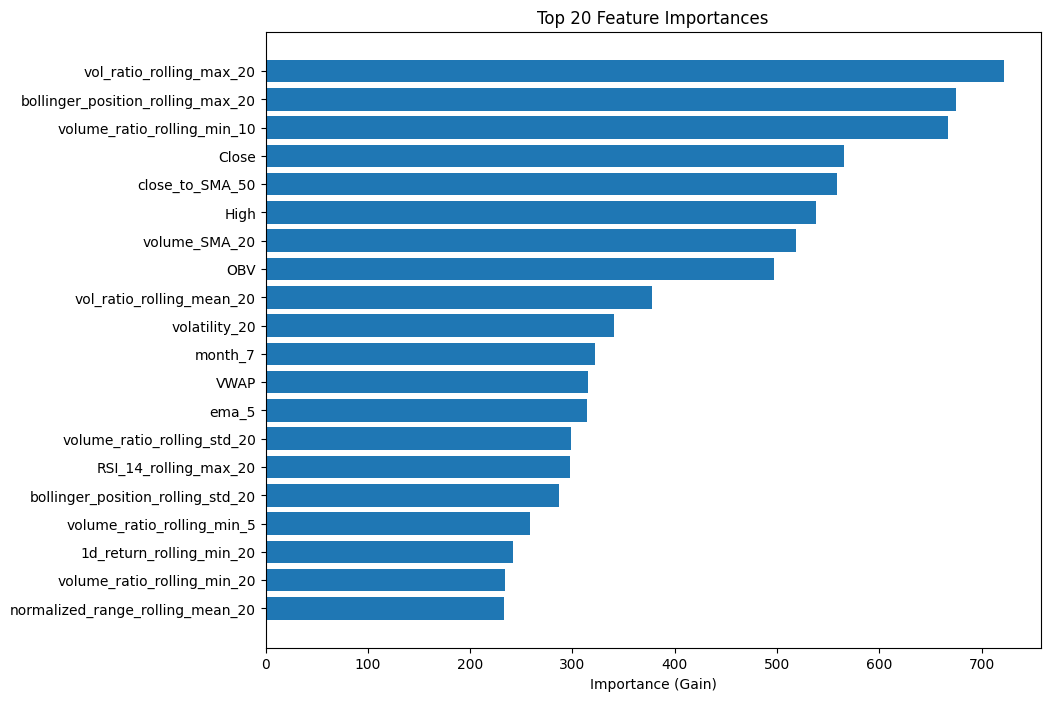

In [100]:
# 6️⃣ Feature Importance
import matplotlib.pyplot as plt

feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': final_model.feature_importance(importance_type='gain')
}).sort_values(by='Importance', ascending=False)

print("\nTop 20 Important Features:")
print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature'].head(20)[::-1], feat_imp['Importance'].head(20)[::-1])
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance (Gain)")
plt.show()


PROBABILITY RANGE ANALYSIS:
Min probability: 0.388
Max probability: 0.578
Mean probability: 0.479
Std probability: 0.048
THRESHOLD ANALYSIS FOR TRADING STRATEGY
Threshold: 0.3 | Acc: 0.561 | Prec: 0.561 | Rec: 1.000 | F1: 0.719 | TP: 254 | FP: 199
Threshold: 0.4 | Acc: 0.512 | Prec: 0.539 | Rec: 0.902 | F1: 0.675 | TP: 229 | FP: 196
Threshold: 0.5 | Acc: 0.629 | Prec: 0.772 | Rec: 0.480 | F1: 0.592 | TP: 122 | FP:  36
Threshold: 0.6 | Acc: 0.439 | Prec: 0.000 | Rec: 0.000 | F1: 0.000 | TP:   0 | FP:   0
Threshold: 0.7 | Acc: 0.439 | Prec: 0.000 | Rec: 0.000 | F1: 0.000 | TP:   0 | FP:   0


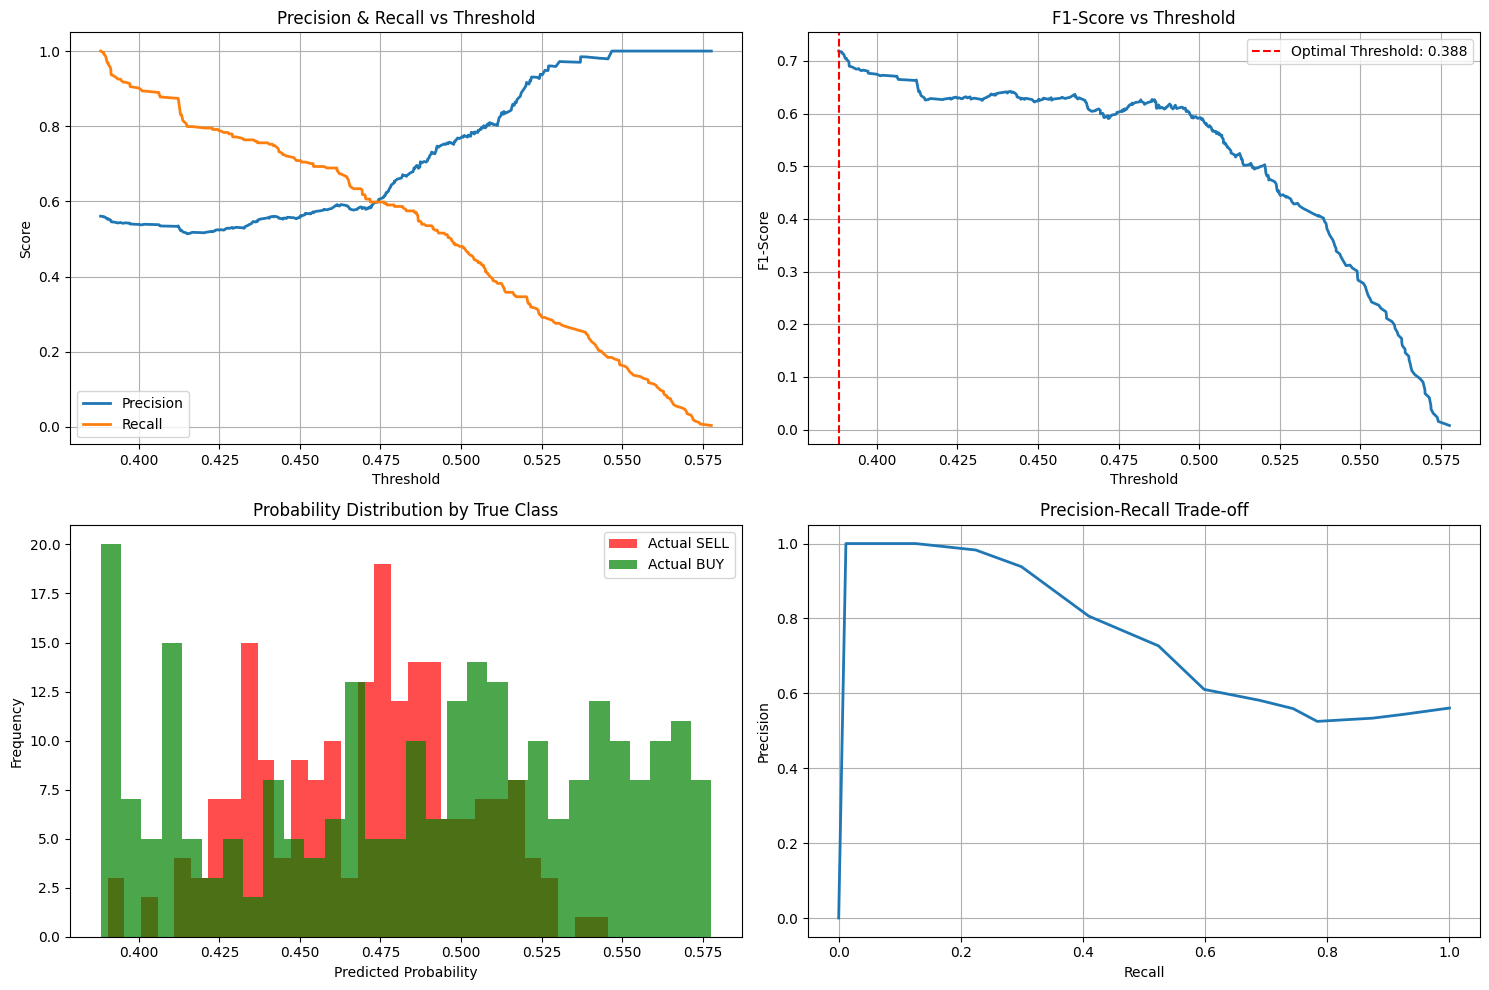


🎯 RECOMMENDED OPTIMAL THRESHOLD: 0.388

PERFORMANCE WITH OPTIMAL THRESHOLD 0.388:

COMPREHENSIVE EVALUATION: Optimized LightGBM
Accuracy:  0.558
Precision: 0.560
Recall:    0.996
F1-Score:  0.717

Confusion Matrix:
                 Predicted 0   Predicted 1
Actual 0 (SELL)          0            199
Actual 1 (BUY)           1            253

Class Distribution:
Class 0 (SELL): 199 samples
Class 1 (BUY):  254 samples
Specificity: 0.000


(0.5584988962472406, 0.5597345132743363, 0.9960629921259843, 0.71671388101983)

In [101]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc, precision_score, recall_score

def find_optimal_threshold(y_true, y_proba, strategy='f1'):
    """
    Find optimal threshold based on different trading strategies
    """
    # Get precision-recall curve data
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    
    # Get ROC curve data
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_proba)
    
    if strategy == 'f1':
        # Maximize F1-score (balanced approach)
        optimal_idx = np.argmax(f1_scores[:-1])  # Exclude last NaN
        optimal_threshold = thresholds[optimal_idx]
        metric_value = f1_scores[optimal_idx]
        
    elif strategy == 'high_precision':
        # High precision (avoid false BUY signals)
        # Find threshold where precision >= 0.7
        high_precision_idx = np.where(precision[:-1] >= 0.7)[0]
        if len(high_precision_idx) > 0:
            optimal_idx = high_precision_idx[0]
            optimal_threshold = thresholds[optimal_idx]
            metric_value = precision[optimal_idx]
        else:
            optimal_threshold = 0.5
            metric_value = precision[np.argmin(np.abs(thresholds - 0.5))]
    
    elif strategy == 'high_recall':
        # High recall (catch most BUY opportunities)
        # Find threshold where recall >= 0.7
        high_recall_idx = np.where(recall[:-1] >= 0.7)[0]
        if len(high_recall_idx) > 0:
            optimal_idx = high_recall_idx[-1]  # Last one meeting criteria
            optimal_threshold = thresholds[optimal_idx]
            metric_value = recall[optimal_idx]
        else:
            optimal_threshold = 0.5
            metric_value = recall[np.argmin(np.abs(thresholds - 0.5))]
    
    return optimal_threshold, metric_value, precision, recall, thresholds

def evaluate_multiple_thresholds(y_true, y_proba):
    """Evaluate performance at different threshold levels"""
    thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
    
    print("THRESHOLD ANALYSIS FOR TRADING STRATEGY")
    print("=" * 60)
    
    results = []
    for threshold in thresholds:
        y_pred = (y_proba > threshold).astype(int)
        
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        # Trading-specific metrics
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        # Avoid division by zero
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False negative rate
        
        results.append({
            'threshold': threshold,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'specificity': specificity,
            'false_negative_rate': fnr,
            'true_positives': tp,
            'false_positives': fp
        })
        
        print(f"Threshold: {threshold:.1f} | "
              f"Acc: {accuracy:.3f} | "
              f"Prec: {precision:.3f} | "
              f"Rec: {recall:.3f} | "
              f"F1: {f1:.3f} | "
              f"TP: {tp:3d} | FP: {fp:3d}")
    
    return results

def plot_threshold_analysis(y_true, y_proba):
    """Visualize threshold selection"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Precision-Recall Curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    ax1.plot(thresholds, precision[:-1], label='Precision', linewidth=2)
    ax1.plot(thresholds, recall[:-1], label='Recall', linewidth=2)
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Score')
    ax1.set_title('Precision & Recall vs Threshold')
    ax1.legend()
    ax1.grid(True)
    
    # 2. F1-Score vs Threshold
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
    optimal_idx = np.argmax(f1_scores)
    ax2.plot(thresholds, f1_scores, linewidth=2)
    ax2.axvline(x=thresholds[optimal_idx], color='red', linestyle='--', 
                label=f'Optimal Threshold: {thresholds[optimal_idx]:.3f}')
    ax2.set_xlabel('Threshold')
    ax2.set_ylabel('F1-Score')
    ax2.set_title('F1-Score vs Threshold')
    ax2.legend()
    ax2.grid(True)
    
    # 3. Probability Distribution
    ax3.hist(y_proba[y_true == 0], bins=30, alpha=0.7, label='Actual SELL', color='red')
    ax3.hist(y_proba[y_true == 1], bins=30, alpha=0.7, label='Actual BUY', color='green')
    ax3.set_xlabel('Predicted Probability')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Probability Distribution by True Class')
    ax3.legend()
    
    # 4. Trade-off analysis
    thresholds_test = np.linspace(0.1, 0.9, 50)
    precision_values = []
    recall_values = []
    
    for thresh in thresholds_test:
        y_pred = (y_proba > thresh).astype(int)
        precision_values.append(precision_score(y_true, y_pred, zero_division=0))
        recall_values.append(recall_score(y_true, y_pred, zero_division=0))
    
    ax4.plot(recall_values, precision_values, linewidth=2)
    ax4.set_xlabel('Recall')
    ax4.set_ylabel('Precision')
    ax4.set_title('Precision-Recall Trade-off')
    ax4.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return thresholds[optimal_idx]

# USAGE:
# Get probabilities from your model
y_pred_proba = final_model.predict(X_test)

# If it's 2D array (probabilities for both classes)
if y_pred_proba.ndim == 2:
    y_pred_proba = y_pred_proba[:, 1]  # Take probabilities for class 1 (BUY)

print("PROBABILITY RANGE ANALYSIS:")
print(f"Min probability: {y_pred_proba.min():.3f}")
print(f"Max probability: {y_pred_proba.max():.3f}")
print(f"Mean probability: {y_pred_proba.mean():.3f}")
print(f"Std probability: {y_pred_proba.std():.3f}")

# Analyze different thresholds
results = evaluate_multiple_thresholds(y_test, y_pred_proba)

# Find optimal threshold
optimal_threshold = plot_threshold_analysis(y_test, y_pred_proba)

print(f"\n🎯 RECOMMENDED OPTIMAL THRESHOLD: {optimal_threshold:.3f}")

# Evaluate with optimal threshold
y_pred_optimal = (y_pred_proba > optimal_threshold).astype(int)
print(f"\nPERFORMANCE WITH OPTIMAL THRESHOLD {optimal_threshold:.3f}:")
comprehensive_evaluation(y_test, y_pred_optimal, "Optimized LightGBM")

In [102]:
def setup_test_set(df_with_features, test_size=0.2):
    """
    Properly set up test set for time series data
    """
    # 1. Sort by date to maintain chronological order
    df_sorted = df_with_features.sort_values('Date').reset_index(drop=True)
    
    # 2. Create time-based split
    split_idx = int(len(df_sorted) * (1 - test_size))
    
    # 3. Create masks
    train_mask = np.zeros(len(df_sorted), dtype=bool)
    test_mask = np.zeros(len(df_sorted), dtype=bool)
    
    train_mask[:split_idx] = True
    test_mask[split_idx:] = True
    
    # 4. Split the data
    train_df = df_sorted[train_mask].copy()
    test_df = df_sorted[test_mask].copy()
    
    print(f"Dataset split:")
    print(f"  Total samples: {len(df_sorted)}")
    print(f"  Training: {len(train_df)} samples ({train_df['Date'].min()} to {train_df['Date'].max()})")
    print(f"  Test: {len(test_df)} samples ({test_df['Date'].min()} to {test_df['Date'].max()})")
    
    return train_df, test_df, train_mask, test_mask

# Usage
train_df, df_test, train_mask, test_mask = setup_test_set(df_with_features)

# Now you can use test_df for your trading analysis
print(f"Test set contains '20d_fwd_return': {'20d_fwd_return' in test_df.columns}")

if '20d_fwd_return' in test_df.columns:
    print(f"Average 20-day return in test set: {test_df['20d_fwd_return'].mean():.3f}")

Dataset split:
  Total samples: 2263
  Training: 1810 samples (2011-06-01 00:00:00 to 2019-04-02 00:00:00)
  Test: 453 samples (2019-04-03 00:00:00 to 2021-01-29 00:00:00)
Test set contains '20d_fwd_return': True
Average 20-day return in test set: 0.092


In [ ]:
X_test = df_test[feature_columns]
y_pred = model.predict(X_test)
df_test['pred'] = y_pred
df_test.head()

,Date,Symbol,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,...,high_volatility_flag_lag_5,volume_spike_flag,large_move_flag,20d_fwd_return,60d_fwd_return,20d_signal,60d_signal,20d_target,60d_target,pred
1810,2019-04-03,ADANIPORTS,0.783436,0.778252,0.778942,0.820827,0.790198,0.794671,0.795285,0.119490,...,0.0,0,0,-0.061299,0.199678,SELL,BUY,0,1,1
1811,2019-04-04,ADANIPORTS,0.794527,0.786432,0.758695,0.794915,0.780058,0.785989,0.774583,-0.182482,...,0.0,0,0,-0.063817,0.212929,SELL,BUY,0,1,1
1812,2019-04-05,ADANIPORTS,0.785847,0.771997,0.791329,0.808116,0.821342,0.819509,0.806336,0.021142,...,0.0,0,0,-0.136833,0.090045,SELL,BUY,0,1,0
1813,2019-04-08,ADANIPORTS,0.819361,0.816744,0.788471,0.797115,0.780058,0.784542,0.780326,0.090149,...,0.0,0,0,-0.045185,0.110042,SELL,BUY,0,1,0
1814,2019-04-09,ADANIPORTS,0.784400,0.775606,0.756551,0.786604,0.789474,0.788401,0.765946,-0.322631,...,0.0,0,0,-0.097574,0.148656,SELL,BUY,0,1,0


In [155]:
df_test

,Date,Symbol,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,...,volume_spike_flag,large_move_flag,20d_fwd_return,60d_fwd_return,20d_signal,60d_signal,20d_target,60d_target,pred,corpus_after_trade
1810,2019-04-03,ADANIPORTS,0.783436,0.778252,0.778942,0.820827,0.790198,0.794671,0.795285,0.119490,...,0,0,-0.061299,0.199678,SELL,BUY,0,1,1,29925.000000
1811,2019-04-04,ADANIPORTS,0.794527,0.786432,0.758695,0.794915,0.780058,0.785989,0.774583,-0.182482,...,0,0,-0.063817,0.212929,SELL,BUY,0,1,1,29850.187500
1812,2019-04-05,ADANIPORTS,0.785847,0.771997,0.791329,0.808116,0.821342,0.819509,0.806336,0.021142,...,0,0,-0.136833,0.090045,SELL,BUY,0,1,0,29850.187500
1813,2019-04-08,ADANIPORTS,0.819361,0.816744,0.788471,0.797115,0.780058,0.784542,0.780326,0.090149,...,0,0,-0.045185,0.110042,SELL,BUY,0,1,0,29850.187500
1814,2019-04-09,ADANIPORTS,0.784400,0.775606,0.756551,0.786604,0.789474,0.788401,0.765946,-0.322631,...,0,0,-0.097574,0.148656,SELL,BUY,0,1,0,29850.187500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2258,2021-01-22,ADANIPORTS,1.593321,1.592350,1.594569,1.562501,1.533800,1.536456,1.578048,1.699710,...,0,0,0.433193,0.611963,BUY,BUY,1,1,0,257974.939501
2259,2021-01-25,ADANIPORTS,1.536178,1.561075,1.546689,1.515077,1.477789,1.477856,1.513192,1.307671,...,0,0,0.451512,0.735930,BUY,BUY,1,1,0,257974.939501
2260,2021-01-27,ADANIPORTS,1.477589,1.490106,1.492139,1.468630,1.445196,1.454705,1.472560,2.491728,...,0,0,0.485221,0.753941,BUY,BUY,1,1,0,257974.939501
2261,2021-01-28,ADANIPORTS,1.454442,1.429723,1.453788,1.441985,1.462820,1.455911,1.450990,1.266182,...,0,0,0.613519,0.754145,BUY,BUY,1,1,0,257974.939501


In [105]:
corpus = 30000
trade_amount = 1000

for i, row in df_test.iterrows():
    if row['pred'] == 1:
        fwd_return = row['20d_fwd_return']
        # Cap the loss at -5%
        effective_return = max(fwd_return, -0.05)
        
        # Profit or loss for this trade
        profit = trade_amount * effective_return
        
        # Update corpus
        corpus += profit

print("Final Corpus Value:", round(corpus, 2))


Final Corpus Value: 73804.15


💰 Final Corpus Value: ₹257974.94
📈 Total Trades Taken: 197


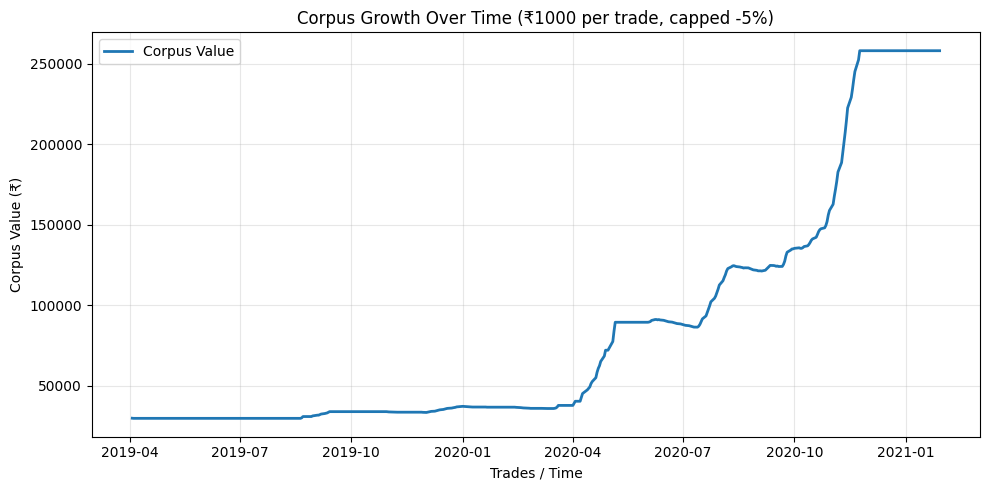

In [106]:
import matplotlib.pyplot as plt

# Initialize parameters
corpus = 30000
trade_amount = 1000
corpus_history = []

# Run simulation
for i, row in df_test.iterrows():
    trade_amount = corpus/20
    if row['pred'] == 1:
        fwd_return = row['20d_fwd_return']
        effective_return = max(fwd_return, -0.05)  # cap loss at -5%
        profit = trade_amount * effective_return
        corpus += profit
    corpus_history.append(corpus)

# Add to DataFrame for tracking
df_test['corpus_after_trade'] = corpus_history

buy_points = df_test[df_test['pred'] == 1]


# Print final corpus
print(f"💰 Final Corpus Value: ₹{round(corpus, 2)}")
print(f"📈 Total Trades Taken: {df_test['pred'].sum()}")

# Plot corpus evolution
plt.figure(figsize=(10, 5))
plt.plot(df_test['Date'], df_test['corpus_after_trade'], label='Corpus Value', linewidth=2)
plt.title("Corpus Growth Over Time (₹1000 per trade, capped -5%)")
plt.xlabel("Trades / Time")
plt.ylabel("Corpus Value (₹)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [201]:
df_unseen = pd.read_csv('ADANIPORTS 2024 -- 2025.csv')

df_unseen['Symbol'] = 'ADANIPORTS'
df_unseen = df_unseen.drop(['52W H ', '52W L '], axis=1)

In [202]:
df_unseen.columns

Index(['Date ', 'series ', 'OPEN ', 'HIGH ', 'LOW ', 'PREV. CLOSE ', 'ltp ',
       'close ', 'vwap ', 'VOLUME ', 'VALUE ', 'No of trades ', 'Symbol'],
      dtype='object')

In [203]:
rename_map = {
    'Date ': 'Date',
    'series ': 'Series',
    'OPEN ': 'Open',
    'HIGH ': 'High',
    'LOW ': 'Low',
    'PREV. CLOSE ': 'Prev Close',
    'ltp ': 'Last',
    'close ': 'Close',
    'vwap ': 'VWAP',
    'VOLUME ': 'Volume',
    'VALUE ': 'Turnover',
    'No of trades ': 'Trades'
}
df_unseen = df_unseen.rename(columns=rename_map)


In [204]:
df_unseen['Date'] = pd.to_datetime(df_unseen['Date'])
df_unseen = df_unseen.sort_values(['Date']).reset_index(drop=True)

df_unseen.columns


Index(['Date', 'Series', 'Open', 'High', 'Low', 'Prev Close', 'Last', 'Close',
       'VWAP', 'Volume', 'Turnover', 'Trades', 'Symbol'],
      dtype='object')

In [205]:
df_unseen

,Date,Series,Open,High,Low,Prev Close,Last,Close,VWAP,Volume,Turnover,Trades,Symbol
0,2024-11-13,EQ,"1,322.00","1,329.25","1,284.85","1,326.00","1,287.35","1,287.90","1,301.38","14,37,072","1,87,01,77,239.25","94,055",ADANIPORTS
1,2024-11-14,EQ,"1,289.95","1,296.65","1,260.65","1,287.90","1,264.95","1,264.55","1,272.67","29,63,013","3,77,09,32,012.10","1,52,378",ADANIPORTS
2,2024-11-18,EQ,"1,264.00","1,288.90","1,261.30","1,264.55","1,279.20","1,279.30","1,275.75","14,45,637","1,84,42,72,542.35","95,416",ADANIPORTS
3,2024-11-19,EQ,"1,285.00","1,321.45","1,282.00","1,279.30","1,287.20","1,289.65","1,304.76","26,31,778","3,43,38,51,541.55","90,392",ADANIPORTS
4,2024-11-21,EQ,"1,160.70","1,160.70",995.65,"1,289.65","1,119.05","1,114.65","1,080.76","4,69,26,687","50,71,63,19,514.70","8,48,188",ADANIPORTS
...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,2025-11-06,EQ,"1,452.10","1,466.30","1,434.30","1,444.40","1,435.70","1,436.80","1,450.67","27,45,063","3,98,21,68,706.10","89,710",ADANIPORTS
243,2025-11-07,EQ,"1,435.00","1,464.00","1,425.00","1,436.80","1,448.90","1,448.30","1,447.83","21,84,538","3,16,28,38,310.80","77,253",ADANIPORTS
244,2025-11-10,EQ,"1,452.20","1,463.90","1,441.00","1,448.30","1,444.00","1,444.90","1,448.77","11,61,695","1,68,30,26,465.00","56,441",ADANIPORTS
245,2025-11-11,EQ,"1,453.00","1,476.00","1,437.80","1,444.90","1,474.10","1,474.40","1,461.14","22,58,827","3,30,04,67,781.20","74,892",ADANIPORTS


In [206]:
print(df_unseen.columns.tolist())


['Date', 'Series', 'Open', 'High', 'Low', 'Prev Close', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Symbol']


In [207]:
# Clean numeric columns with commas
for col in ['Volume', 'Turnover', 'Trades']:
    df_unseen[col] = (
        df_unseen[col]
        .astype(str)                 # ensure string for replace
        .str.replace(',', '', regex=False)  # remove commas
        .astype(float)               # convert to float
    )


In [208]:
print(df_unseen[['Date']].dtypes)


Date    datetime64[ns]
dtype: object


In [209]:
df_unseen['Symbol'].iloc[0] = 'MUNDRA'

In [210]:
df_unseen.dtypes

Date          datetime64[ns]
Series                object
Open                  object
High                  object
Low                   object
Prev Close            object
Last                  object
Close                 object
VWAP                  object
Volume               float64
Turnover             float64
Trades               float64
Symbol                object
dtype: object

In [211]:
df_unseen

,Date,Series,Open,High,Low,Prev Close,Last,Close,VWAP,Volume,Turnover,Trades,Symbol
0,2024-11-13,EQ,"1,322.00","1,329.25","1,284.85","1,326.00","1,287.35","1,287.90","1,301.38",1437072.0,1.870177e+09,94055.0,MUNDRA
1,2024-11-14,EQ,"1,289.95","1,296.65","1,260.65","1,287.90","1,264.95","1,264.55","1,272.67",2963013.0,3.770932e+09,152378.0,ADANIPORTS
2,2024-11-18,EQ,"1,264.00","1,288.90","1,261.30","1,264.55","1,279.20","1,279.30","1,275.75",1445637.0,1.844273e+09,95416.0,ADANIPORTS
3,2024-11-19,EQ,"1,285.00","1,321.45","1,282.00","1,279.30","1,287.20","1,289.65","1,304.76",2631778.0,3.433852e+09,90392.0,ADANIPORTS
4,2024-11-21,EQ,"1,160.70","1,160.70",995.65,"1,289.65","1,119.05","1,114.65","1,080.76",46926687.0,5.071632e+10,848188.0,ADANIPORTS
...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,2025-11-06,EQ,"1,452.10","1,466.30","1,434.30","1,444.40","1,435.70","1,436.80","1,450.67",2745063.0,3.982169e+09,89710.0,ADANIPORTS
243,2025-11-07,EQ,"1,435.00","1,464.00","1,425.00","1,436.80","1,448.90","1,448.30","1,447.83",2184538.0,3.162838e+09,77253.0,ADANIPORTS
244,2025-11-10,EQ,"1,452.20","1,463.90","1,441.00","1,448.30","1,444.00","1,444.90","1,448.77",1161695.0,1.683026e+09,56441.0,ADANIPORTS
245,2025-11-11,EQ,"1,453.00","1,476.00","1,437.80","1,444.90","1,474.10","1,474.40","1,461.14",2258827.0,3.300468e+09,74892.0,ADANIPORTS


In [213]:
cols_to_float = [
    'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP'
]

for col in cols_to_float:
    df_unseen[col] = (
        df_unseen[col]
        .astype(str)                      # ensure string for replacements
        .str.replace(',', '', regex=False) # remove commas
        .str.replace('₹', '', regex=False) # remove currency symbols
        .str.replace('%', '', regex=False) # remove percentage signs if any
        .str.strip()                       # remove leading/trailing spaces
    )
    df_unseen[col] = pd.to_numeric(df_unseen[col], errors='coerce')


In [214]:
df_unseen.dtypes

Date          datetime64[ns]
Series                object
Open                 float64
High                 float64
Low                  float64
Prev Close           float64
Last                 float64
Close                float64
VWAP                 float64
Volume               float64
Turnover             float64
Trades               float64
Symbol                object
dtype: object

In [215]:
df_unseen

,Date,Series,Open,High,Low,Prev Close,Last,Close,VWAP,Volume,Turnover,Trades,Symbol
0,2024-11-13,EQ,1322.00,1329.25,1284.85,1326.00,1287.35,1287.90,1301.38,1437072.0,1.870177e+09,94055.0,MUNDRA
1,2024-11-14,EQ,1289.95,1296.65,1260.65,1287.90,1264.95,1264.55,1272.67,2963013.0,3.770932e+09,152378.0,ADANIPORTS
2,2024-11-18,EQ,1264.00,1288.90,1261.30,1264.55,1279.20,1279.30,1275.75,1445637.0,1.844273e+09,95416.0,ADANIPORTS
3,2024-11-19,EQ,1285.00,1321.45,1282.00,1279.30,1287.20,1289.65,1304.76,2631778.0,3.433852e+09,90392.0,ADANIPORTS
4,2024-11-21,EQ,1160.70,1160.70,995.65,1289.65,1119.05,1114.65,1080.76,46926687.0,5.071632e+10,848188.0,ADANIPORTS
...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,2025-11-06,EQ,1452.10,1466.30,1434.30,1444.40,1435.70,1436.80,1450.67,2745063.0,3.982169e+09,89710.0,ADANIPORTS
243,2025-11-07,EQ,1435.00,1464.00,1425.00,1436.80,1448.90,1448.30,1447.83,2184538.0,3.162838e+09,77253.0,ADANIPORTS
244,2025-11-10,EQ,1452.20,1463.90,1441.00,1448.30,1444.00,1444.90,1448.77,1161695.0,1.683026e+09,56441.0,ADANIPORTS
245,2025-11-11,EQ,1453.00,1476.00,1437.80,1444.90,1474.10,1474.40,1461.14,2258827.0,3.300468e+09,74892.0,ADANIPORTS


In [216]:
# With your actual data
engineer_unseen = FinancialFeatureEngineer(offset_days=20)

engineer_unseen.fitted_volatility_threshold = engineer.fitted_volatility_threshold

df_with_features_unseen = engineer_unseen.fit_transform(df_unseen)


# Get feature categories
categories_unseen = engineer_unseen.get_feature_categories(df_with_features_unseen)

# Prepare for ML training
feature_columns_unseen = [col for col in df_with_features_unseen.columns 
                  if col not in ['Date', 'Symbol', '20d_fwd_return', '60d_fwd_return', 
                               '20d_signal', '60d_signal', '20d_target', '60d_target']]

Starting comprehensive feature engineering...
Total features before normalization: ['Date', 'Series', 'Open', 'High', 'Low', 'Prev Close', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Symbol']
Normalizing ['Open', 'High', 'Low', 'Prev Close', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades'] numeric features...
✓ Features normalized using RobustScaler
✓ Returns and moving averages calculated
✓ Momentum indicators calculated
✓ Volatility features calculated
✓ Volume features calculated
✓ Candlestick features calculated
✓ Time features created
✓ Tier 1 raw lags created
✓ Tier 2 engineered aggregates created
✓ Tier 3 event memory features created
✓ Target variables created
✓ Dataframe cleaned
✓ Removed rows with NaN. Final dataset: 106 rows (from 247)
✓ Feature engineering complete! Total features: 222

Target distribution (20-day):
20d_signal
SELL    85
BUY     21
Name: count, dtype: int64

Target distribution (60-day):
60d_signal
SELL    79
BUY     27
Name: count, dt

In [217]:
df_with_features_unseen

,Date,Open,High,Low,Prev Close,Last,Close,VWAP,Volume,Turnover,...,high_volatility_flag,high_volatility_flag_lag_5,volume_spike_flag,large_move_flag,20d_fwd_return,60d_fwd_return,20d_signal,60d_signal,20d_target,60d_target
61,2025-02-10,-0.771775,-0.811610,-0.792645,-0.770697,-0.771677,-0.780633,-0.807152,0.114867,0.000000,...,1,1.0,0,0,0.050273,-1.243716,BUY,SELL,1,0
62,2025-02-11,-0.797354,-0.806495,-0.848762,-0.778837,-0.792877,-0.798123,-0.824580,1.674460,1.296064,...,1,1.0,0,0,0.063068,-1.422234,BUY,SELL,1,0
63,2025-02-12,-0.815877,-0.876779,-0.912956,-0.796401,-0.832733,-0.845686,-0.867464,0.395001,0.215930,...,1,1.0,0,0,0.049180,-1.404540,BUY,SELL,1,0
64,2025-02-13,-0.843219,-0.843639,-0.882772,-0.844168,-0.920500,-0.919910,-0.837200,0.960699,0.695755,...,1,1.0,0,0,-0.118711,-1.329701,SELL,SELL,0,0
65,2025-02-14,-0.904079,-0.984431,-1.154427,-0.918711,-1.123384,-1.128293,-1.103132,1.463509,0.983812,...,1,1.0,0,1,-0.363327,-1.217013,SELL,SELL,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,2025-08-07,0.114664,0.073843,0.005527,0.176074,0.095400,0.077637,0.022064,0.392021,0.485948,...,1,1.0,0,0,0.159341,5.021978,BUY,BUY,1,1
183,2025-08-08,0.089967,0.069395,0.017005,0.083110,0.000000,-0.009385,0.001717,-0.421253,-0.313322,...,1,1.0,0,0,-25.409091,-56.045455,SELL,SELL,0,0
184,2025-08-11,0.000000,0.031139,0.000000,-0.004284,0.075472,0.052042,0.009916,-0.112522,-0.010464,...,1,1.0,0,1,4.073770,8.647541,BUY,BUY,1,1
185,2025-08-12,0.074972,0.036922,0.061643,0.057406,0.013568,0.014077,0.040523,-0.609975,-0.492101,...,1,1.0,0,0,18.969697,43.606061,BUY,BUY,1,1


In [218]:
# Ensure unseen dataset has the same dummy columns as training
for col in feature_columns:
    if col not in df_with_features_unseen.columns:
        print(f"Adding missing feature column: {col}")
        df_with_features_unseen[col] = 0

# Align column order exactly as training
X_unseen = df_with_features_unseen[feature_columns]


Adding missing feature column: dow_6


In [219]:
X_unseen

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,...,RSI_14_rolling_trend_20,rolling_max_20,rolling_min_20,max_drawdown_20,max_runup_20,price_position_20d,high_volatility_flag,high_volatility_flag_lag_5,volume_spike_flag,large_move_flag
61,-0.770697,-0.771775,-0.811610,-0.792645,-0.771677,-0.780633,-0.807152,0.114867,0.000000,0.544235,...,1.207800,-0.695958,-1.067079,0.000000,0.0,0.771839,1,1.0,0,0
62,-0.778837,-0.797354,-0.806495,-0.848762,-0.792877,-0.798123,-0.824580,1.674460,1.296064,0.986435,...,1.271180,-0.695958,-1.067079,0.000000,0.0,0.724713,1,1.0,0,0
63,-0.796401,-0.815877,-0.876779,-0.912956,-0.832733,-0.845686,-0.867464,0.395001,0.215930,0.809155,...,1.384717,-0.695958,-1.067079,0.000000,0.0,0.596552,1,1.0,0,0
64,-0.844168,-0.843219,-0.843639,-0.882772,-0.920500,-0.919910,-0.837200,0.960699,0.695755,0.836306,...,1.508545,-0.695958,-1.067079,0.000000,0.0,0.396552,1,1.0,0,0
65,-0.918711,-0.904079,-0.984431,-1.154427,-1.123384,-1.128293,-1.103132,1.463509,0.983812,1.503030,...,1.387959,-0.695958,-1.128293,0.000000,0.0,0.000000,1,1.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,0.176074,0.114664,0.073843,0.005527,0.095400,0.077637,0.022064,0.392021,0.485948,0.432526,...,-2.258782,0.552415,0.077637,-0.859459,0.0,0.000000,1,1.0,0,0
183,0.083110,0.089967,0.069395,0.017005,0.000000,-0.009385,0.001717,-0.421253,-0.313322,-0.097357,...,-2.030449,0.552415,-0.009385,-1.016988,0.0,0.000000,1,1.0,0,0
184,-0.004284,0.000000,0.031139,0.000000,0.075472,0.052042,0.009916,-0.112522,-0.010464,0.231008,...,-1.733903,0.552415,-0.009385,-0.905792,0.0,0.109339,1,1.0,0,1
185,0.057406,0.074972,0.036922,0.061643,0.013568,0.014077,0.040523,-0.609975,-0.492101,-0.558587,...,-1.372225,0.552415,-0.009385,-0.974517,0.0,0.041762,1,1.0,0,0


In [235]:
y_pred_unseen = model.predict(X_unseen)
df_with_features_unseen['pred'] = y_pred_unseen
df_with_features_unseen.head()

,Date,Open,High,Low,Prev Close,Last,Close,VWAP,Volume,Turnover,...,large_move_flag,20d_fwd_return,60d_fwd_return,20d_signal,60d_signal,20d_target,60d_target,dow_6,pred,corpus_after_trade
61,2025-02-10,-0.771775,-0.811610,-0.792645,-0.770697,-0.771677,-0.780633,-0.807152,0.114867,0.000000,...,0,0.050273,-1.243716,BUY,SELL,1,0,0,0,30000.0
62,2025-02-11,-0.797354,-0.806495,-0.848762,-0.778837,-0.792877,-0.798123,-0.824580,1.674460,1.296064,...,0,0.063068,-1.422234,BUY,SELL,1,0,0,0,30000.0
63,2025-02-12,-0.815877,-0.876779,-0.912956,-0.796401,-0.832733,-0.845686,-0.867464,0.395001,0.215930,...,0,0.049180,-1.404540,BUY,SELL,1,0,0,0,30000.0
64,2025-02-13,-0.843219,-0.843639,-0.882772,-0.844168,-0.920500,-0.919910,-0.837200,0.960699,0.695755,...,0,-0.118711,-1.329701,SELL,SELL,0,0,0,0,30000.0
65,2025-02-14,-0.904079,-0.984431,-1.154427,-0.918711,-1.123384,-1.128293,-1.103132,1.463509,0.983812,...,1,-0.363327,-1.217013,SELL,SELL,0,0,0,0,30000.0


In [236]:
df_with_features

,Date,Symbol,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,...,high_volatility_flag,high_volatility_flag_lag_5,volume_spike_flag,large_move_flag,20d_fwd_return,60d_fwd_return,20d_signal,60d_signal,20d_target,60d_target
866,2011-06-01,MUNDRAPORT,-0.269005,-0.271606,-0.272034,-0.248659,-0.260019,-0.256755,-0.262296,0.070914,...,0,0.0,0,0,0.129614,0.443317,BUY,BUY,1,1
867,2011-06-02,MUNDRAPORT,-0.256709,-0.262465,-0.274655,-0.254037,-0.271366,-0.270019,-0.271513,-0.262802,...,0,0.0,0,0,-0.012503,0.369742,SELL,BUY,0,1
868,2011-06-03,MUNDRAPORT,-0.269970,-0.274493,-0.285850,-0.258681,-0.272091,-0.270983,-0.277063,-0.458682,...,0,0.0,0,0,-0.023138,0.279434,SELL,BUY,0,1
869,2011-06-06,MUNDRAPORT,-0.270934,-0.279305,-0.293949,-0.259415,-0.276919,-0.276771,-0.281550,-0.702611,...,0,0.0,0,0,-0.017426,0.135053,SELL,BUY,0,1
870,2011-06-07,MUNDRAPORT,-0.276721,-0.282432,-0.286089,-0.272615,-0.291405,-0.289311,-0.289127,-0.074290,...,0,0.0,0,0,-0.044178,-0.004168,SELL,SELL,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3257,2021-01-22,ADANIPORTS,1.593321,1.592350,1.594569,1.562501,1.533800,1.536456,1.578048,1.699710,...,0,0.0,0,0,0.433193,0.611963,BUY,BUY,1,1
3258,2021-01-25,ADANIPORTS,1.536178,1.561075,1.546689,1.515077,1.477789,1.477856,1.513192,1.307671,...,0,0.0,0,0,0.451512,0.735930,BUY,BUY,1,1
3259,2021-01-27,ADANIPORTS,1.477589,1.490106,1.492139,1.468630,1.445196,1.454705,1.472560,2.491728,...,0,0.0,0,0,0.485221,0.753941,BUY,BUY,1,1
3260,2021-01-28,ADANIPORTS,1.454442,1.429723,1.453788,1.441985,1.462820,1.455911,1.450990,1.266182,...,0,0.0,0,0,0.613519,0.754145,BUY,BUY,1,1


📊 Model Performance Metrics
Accuracy : 0.6415
Precision: 0.1304
Recall   : 0.1429
F1-score : 0.1364

Detailed classification report:
              precision    recall  f1-score   support

        SELL       0.78      0.76      0.77        85
         BUY       0.13      0.14      0.14        21

    accuracy                           0.64       106
   macro avg       0.46      0.45      0.46       106
weighted avg       0.65      0.64      0.65       106



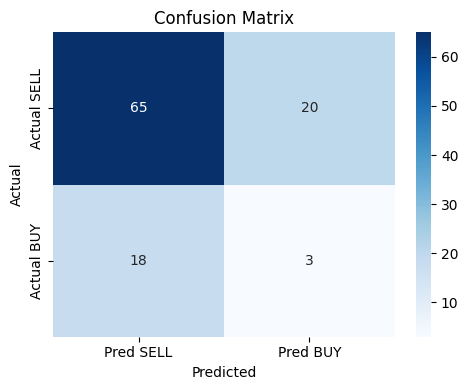

In [246]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Prepare data ---
df = df_with_features_unseen.copy()

# Convert ground truth and predictions
y_true = (df['20d_signal'] == 'BUY').astype(int)   # 1 for BUY, 0 for SELL
y_pred = df['pred'].astype(int)                    # ensure int 0/1

# --- Compute core metrics ---
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)

print("📊 Model Performance Metrics")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# --- Detailed classification report ---
print("\nDetailed classification report:")
print(classification_report(y_true, y_pred, target_names=['SELL', 'BUY'], zero_division=0))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred SELL', 'Pred BUY'],
            yticklabels=['Actual SELL', 'Actual BUY'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [237]:
y_pred_unseen

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [238]:
df_with_features_unseen['20d_target'].tolist()

[1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0]

In [239]:
print(df_with_features_unseen.to_string())

          Date      Open      High       Low  Prev Close      Last     Close      VWAP    Volume  Turnover    Trades      Symbol  1d_return    5d_ROC   10d_ROC    20d_ROC  momentum_ratio    SMA_10    SMA_20    SMA_50    EMA_12    EMA_26     ema_5    ema_20  close_to_SMA_10  close_to_SMA_20  close_to_SMA_50  ema_ratio      MACD  MACD_signal  MACD_histogram     RSI_14  williams_R_14  volatility_10  volatility_20  volatility_60  normalized_range  rolling_std_5  rolling_std_20  volatility_ratio    ATR_14  true_range    atr_14  bollinger_upper  bollinger_lower  bollinger_position  sharpe_20  volume_SMA_20  volume_SMA_10  volume_SMA_5  volume_ratio  vol_ma_5  vol_ma_20  vol_ratio  vwap_ratio        OBV  volume_return_corr_20  candle_body  upper_shadow  lower_shadow  bullish_engulfing  day_of_week  month  day_of_month  is_month_start  is_month_end  is_quarter_end  dow_0  dow_1  dow_2  dow_3  dow_4  dow_5  month_1  month_2  month_3  month_4  month_5  month_6  month_7  month_8  month_9  month_1

💰 Final Corpus Value: ₹56754.8
📈 Total Trades Taken: 23


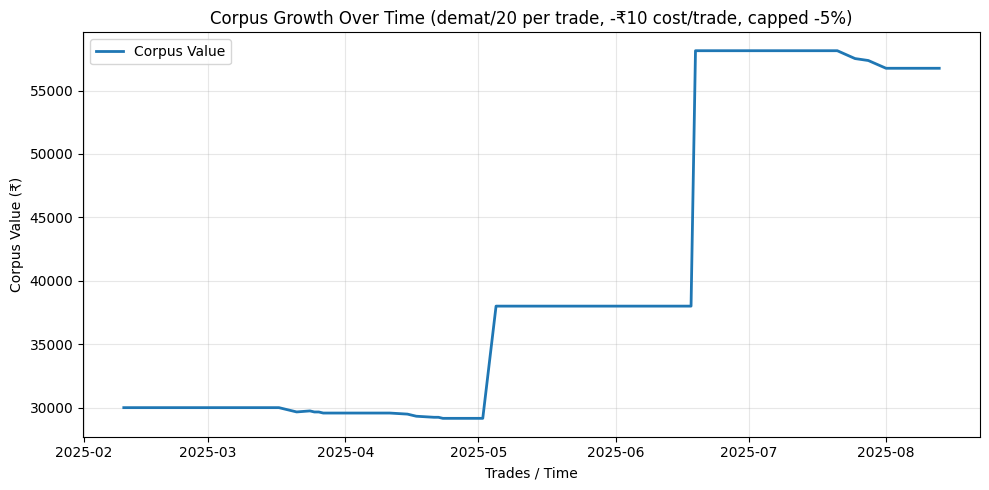

In [240]:
import matplotlib.pyplot as plt

# Initialize parameters
in_market = 0
demat = 30000           # available cash balance to trade
networth = in_market+demat          # total net worth tracker (demat + invested returns)

corpus_history = []

# Run simulation
for i, row in df_with_features_unseen.iterrows():
    # Each trade invests demat/20
    trade_amount = demat / 20

    if row['pred'] == 1 and demat > trade_amount:
        fwd_return = row['20d_fwd_return']
        effective_return = max(fwd_return, -0.05)  # cap max loss at -5%

        profit = trade_amount * effective_return
        demat -= 10  # deduct ₹10 for brokerage/slippage
        demat += profit  # add back profit/loss to demat cash

    # corpus reflects total account value
    corpus = demat
    corpus_history.append(corpus)

# Add corpus history for plotting
df_with_features_unseen['corpus_after_trade'] = corpus_history

# Print summary
print(f"💰 Final Corpus Value: ₹{round(corpus, 2)}")
print(f"📈 Total Trades Taken: {df_with_features_unseen['pred'].sum()}")

# Plot corpus evolution
plt.figure(figsize=(10, 5))
plt.plot(df_with_features_unseen['Date'], df_with_features_unseen['corpus_after_trade'],
         label='Corpus Value', linewidth=2)
plt.title("Corpus Growth Over Time (demat/20 per trade, -₹10 cost/trade, capped -5%)")
plt.xlabel("Trades / Time")
plt.ylabel("Corpus Value (₹)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [242]:
df_with_features_unseen

,Date,Open,High,Low,Prev Close,Last,Close,VWAP,Volume,Turnover,...,large_move_flag,20d_fwd_return,60d_fwd_return,20d_signal,60d_signal,20d_target,60d_target,dow_6,pred,corpus_after_trade
61,2025-02-10,-0.771775,-0.811610,-0.792645,-0.770697,-0.771677,-0.780633,-0.807152,0.114867,0.000000,...,0,0.050273,-1.243716,BUY,SELL,1,0,0,0,30000.000000
62,2025-02-11,-0.797354,-0.806495,-0.848762,-0.778837,-0.792877,-0.798123,-0.824580,1.674460,1.296064,...,0,0.063068,-1.422234,BUY,SELL,1,0,0,0,30000.000000
63,2025-02-12,-0.815877,-0.876779,-0.912956,-0.796401,-0.832733,-0.845686,-0.867464,0.395001,0.215930,...,0,0.049180,-1.404540,BUY,SELL,1,0,0,0,30000.000000
64,2025-02-13,-0.843219,-0.843639,-0.882772,-0.844168,-0.920500,-0.919910,-0.837200,0.960699,0.695755,...,0,-0.118711,-1.329701,SELL,SELL,0,0,0,0,30000.000000
65,2025-02-14,-0.904079,-0.984431,-1.154427,-0.918711,-1.123384,-1.128293,-1.103132,1.463509,0.983812,...,1,-0.363327,-1.217013,SELL,SELL,0,0,0,0,30000.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,2025-08-07,0.114664,0.073843,0.005527,0.176074,0.095400,0.077637,0.022064,0.392021,0.485948,...,0,0.159341,5.021978,BUY,BUY,1,1,0,0,56754.799323
183,2025-08-08,0.089967,0.069395,0.017005,0.083110,0.000000,-0.009385,0.001717,-0.421253,-0.313322,...,0,-25.409091,-56.045455,SELL,SELL,0,0,0,0,56754.799323
184,2025-08-11,0.000000,0.031139,0.000000,-0.004284,0.075472,0.052042,0.009916,-0.112522,-0.010464,...,1,4.073770,8.647541,BUY,BUY,1,1,0,0,56754.799323
185,2025-08-12,0.074972,0.036922,0.061643,0.057406,0.013568,0.014077,0.040523,-0.609975,-0.492101,...,0,18.969697,43.606061,BUY,BUY,1,1,0,0,56754.799323


In [243]:
X_unseen

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,...,RSI_14_rolling_trend_20,rolling_max_20,rolling_min_20,max_drawdown_20,max_runup_20,price_position_20d,high_volatility_flag,high_volatility_flag_lag_5,volume_spike_flag,large_move_flag
61,-0.770697,-0.771775,-0.811610,-0.792645,-0.771677,-0.780633,-0.807152,0.114867,0.000000,0.544235,...,1.207800,-0.695958,-1.067079,0.000000,0.0,0.771839,1,1.0,0,0
62,-0.778837,-0.797354,-0.806495,-0.848762,-0.792877,-0.798123,-0.824580,1.674460,1.296064,0.986435,...,1.271180,-0.695958,-1.067079,0.000000,0.0,0.724713,1,1.0,0,0
63,-0.796401,-0.815877,-0.876779,-0.912956,-0.832733,-0.845686,-0.867464,0.395001,0.215930,0.809155,...,1.384717,-0.695958,-1.067079,0.000000,0.0,0.596552,1,1.0,0,0
64,-0.844168,-0.843219,-0.843639,-0.882772,-0.920500,-0.919910,-0.837200,0.960699,0.695755,0.836306,...,1.508545,-0.695958,-1.067079,0.000000,0.0,0.396552,1,1.0,0,0
65,-0.918711,-0.904079,-0.984431,-1.154427,-1.123384,-1.128293,-1.103132,1.463509,0.983812,1.503030,...,1.387959,-0.695958,-1.128293,0.000000,0.0,0.000000,1,1.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,0.176074,0.114664,0.073843,0.005527,0.095400,0.077637,0.022064,0.392021,0.485948,0.432526,...,-2.258782,0.552415,0.077637,-0.859459,0.0,0.000000,1,1.0,0,0
183,0.083110,0.089967,0.069395,0.017005,0.000000,-0.009385,0.001717,-0.421253,-0.313322,-0.097357,...,-2.030449,0.552415,-0.009385,-1.016988,0.0,0.000000,1,1.0,0,0
184,-0.004284,0.000000,0.031139,0.000000,0.075472,0.052042,0.009916,-0.112522,-0.010464,0.231008,...,-1.733903,0.552415,-0.009385,-0.905792,0.0,0.109339,1,1.0,0,1
185,0.057406,0.074972,0.036922,0.061643,0.013568,0.014077,0.040523,-0.609975,-0.492101,-0.558587,...,-1.372225,0.552415,-0.009385,-0.974517,0.0,0.041762,1,1.0,0,0


In [244]:
X_train

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,...,RSI_14_rolling_trend_20,rolling_max_20,rolling_min_20,max_drawdown_20,max_runup_20,price_position_20d,high_volatility_flag,high_volatility_flag_lag_5,volume_spike_flag,large_move_flag
0,-0.269005,-0.271606,-0.272034,-0.248659,-0.260019,-0.256755,-0.262296,0.070914,-0.165070,-0.513588,...,3.565968,-0.256755,-0.427733,0.000000,0.000000,1.000000,0,0.0,0,0
1,-0.256709,-0.262465,-0.274655,-0.254037,-0.271366,-0.270019,-0.271513,-0.262802,-0.315365,-0.605638,...,3.416265,-0.256755,-0.418328,0.000000,0.000000,0.917910,0,0.0,0,0
2,-0.269970,-0.274493,-0.285850,-0.258681,-0.272091,-0.270983,-0.277063,-0.458682,-0.402011,-0.647622,...,3.301293,-0.256755,-0.418328,0.000000,0.000000,0.911940,0,0.0,0,0
3,-0.270934,-0.279305,-0.293949,-0.259415,-0.276919,-0.276771,-0.281550,-0.702611,-0.507939,-0.885476,...,2.872843,-0.256755,-0.405305,0.000000,0.000000,0.865260,0,0.0,0,0
4,-0.276721,-0.282432,-0.286089,-0.272615,-0.291405,-0.289311,-0.289127,-0.074290,-0.241514,-0.553728,...,2.464256,-0.256755,-0.405305,0.000000,0.000000,0.780844,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1805,0.729910,0.715222,0.709385,0.743580,0.718976,0.718949,0.724301,0.220280,0.521441,0.488386,...,2.238480,0.731971,0.512522,-0.017791,0.402767,0.940659,0,0.0,0,0
1806,0.718819,0.723161,0.761553,0.753847,0.790198,0.791294,0.768214,1.343321,1.687228,1.945508,...,2.262324,0.791294,0.520962,0.000000,0.518909,1.000000,0,0.0,1,1
1807,0.791151,0.792687,0.777037,0.798827,0.784404,0.776102,0.777382,0.663256,1.006065,0.907420,...,2.170106,0.791294,0.523856,-0.019200,0.481517,0.943192,0,0.0,0,0
1808,0.775961,0.781380,0.779895,0.814961,0.792854,0.799735,0.792728,0.034832,0.374029,0.225022,...,2.021203,0.799735,0.559305,0.000000,0.429871,1.000000,0,0.0,0,0
